In [1]:
from resources.imports import *

from resources.MLdata import load_data, prep_UTdata, remove_outliers, split_data, plot_distribution, locSims, get_stats,\
                             plot_frequency, plot_properties, plot_curve

In [2]:
### GLOBAL PATH INPUTS

pData = 'data/'

pAl          = pData + 'Al/'
pAK          = pAl + 'AK/'
pUTdisNodes  = pAK + 'Ductile-disNodes-FCC-12X16/'
pUTdisNodes2 = pAK + '20_RD02_10mm/'
pUTdisStruts = pAK + 'Ductile-disStruts-FCC-12X16/'
pFTdisNodes  = pAK + 'Fracture-disNodes/'

# Geometry

In [3]:
LAT = 'FCC'
l = 0.010
nnx = 12
nny = 18

# Load Data

In [4]:
PATH  = pUTdisNodes2
dis   = 'disNodes'     # disNodes, disStruts

CSVin  = PATH + f'Ductile-{dis}-IN.csv'
CSVout = PATH + f'Ductile-{dis}-OUT.csv'

In [5]:
IN_df, OUT_df, perIN_df, perOUT_df, dIN_df, dOUT_df = load_data(CSVin, CSVout)

# Prep Data

In [6]:
dIN_r, dOUT_r, xOUT, props_r = prep_UTdata(dIN_df, dOUT_df, perOUT_df, OUT_df)
dIN, dOUT, props, IN_df, OUT_df, dIN_df, dOUT_df = remove_outliers(dIN_r, dOUT_r, props_r, IN_df, OUT_df, dIN_df, dOUT_df)
train_in, train_out, val_in, val_out, test_in, test_out = split_data(dIN[1:], dOUT[1:], PATH, mode="UT", split=0.85)

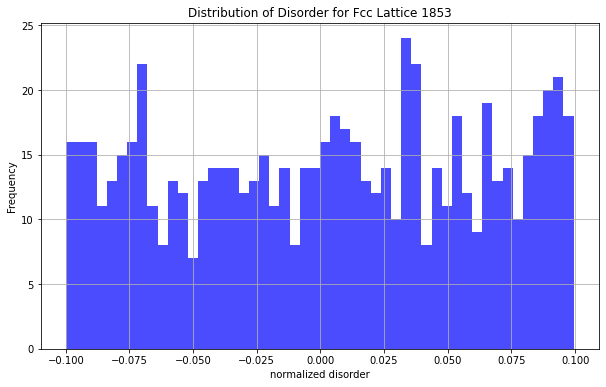

In [7]:
plot_distribution(dIN_df, LAT, l, indx=None, num=1, by="lattice")

In [8]:
stats = get_stats(props)
nSim_max, nSim_min = locSims(props[0], OUT_df)
print(f"UT -- max: {nSim_max}, min: {nSim_min} \nStats: {np.array(stats)/props[0][0]}")

UT -- max: 3575, min: 593 
Stats: [[9.50651102e-01 1.10024908e-01]
 [1.43271245e+03 2.64723687e+01]
 [6.59066508e+05 2.56861270e+03]]


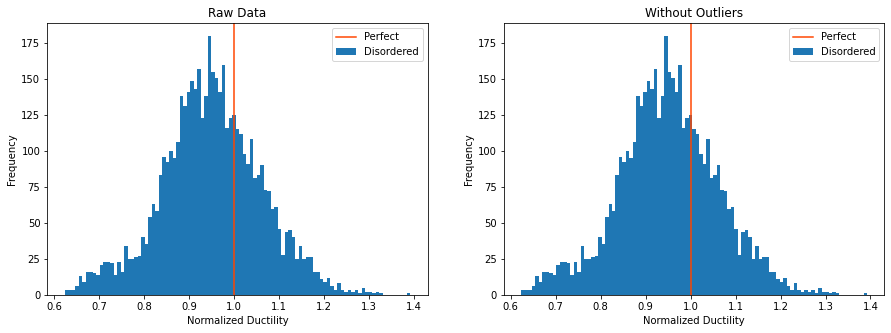

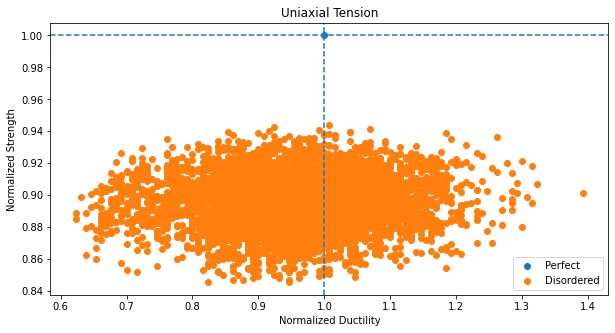

In [9]:
plot_freq = True
plot_props = True

dduct, sstr, sstiff = 0, 1, 2
kk, FF, dd = 0, 2, 3

U1, U2 = dduct, sstr
F1, F2 = kk, dd

if plot_freq:
    plot_frequency(props_r[U1], props[U1], "UT", bins=len(props[U1])//50)
if plot_props:
    plot_properties(props[U1], props[U2], "UT")

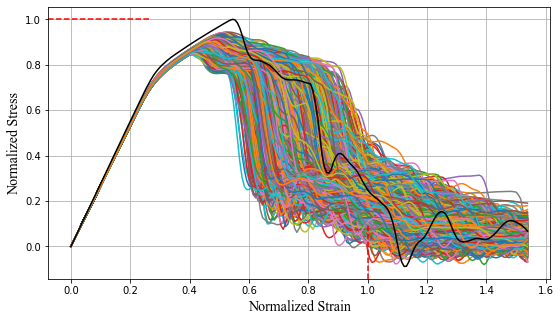

In [10]:
plot_curve(OUT_df, xOUT, "ut", idx=None, q='all')